# 10 · Strategy Iterations and Challenger Roll-out

Two iterations on top of the notebook-09 baseline, framed as a **phased roll-out of the LightGBM challenger**:

| Phase | What LightGBM does | Scope |
|---|---|---|
| 0 — shadow | scores every application, no influence on decisions | none |
| **1 — review-queue triage** | splits the scorecard's grade D (manual review) into *fast-approve* and *full review* | ~15% of volume |
| **2 — dual-score matrix** | joins every decision; the scorecard remains a backstop | all volume |

**Fair comparison:** every rule is set on the validation period and applied unchanged to OOT1 / OOT2, and each new
policy is compared with the baseline **at the same auto-approve / review shares**.

(Also tested during the project and **not adopted**: segment-specific cut-offs — small gains that vanished in OOT2 and
concentrated approvals in thin-file new customers, a fraud-prone segment; and CUSUM alerts — no earlier than fixed
thresholds because the score signal itself arrives late, although CUSUM removed false alarms.)

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from hcrisk.config import PERIOD_LABEL, RES_DIR, savefig
from hcrisk.strategy import GRADE_LABELS, grade_cuts, to_grade

# ================= parameters =================
AGE_MIN = 22
GRADE_SHARES = [0.30, 0.25, 0.20, 0.15, 0.10]       # A-E, as in notebook 09
AUTO_SHARE, REVIEW_SHARE = 0.75, 0.15               # dual matrix targets (same as notebook 09)
SHRINK_M = 200                                      # empirical-Bayes strength for small matrix cells
FAST_SAFETY = 0.90                                  # fast-approve bad rate must be <= 90% of grade C's bad rate
MIN_GROUP = 50
# ==============================================

SC = json.loads((RES_DIR / "08_decision.json").read_text())["chosen_scorecard"]
P = (pl.read_parquet(RES_DIR / "08_predictions.parquet").join(pl.read_parquet(RES_DIR / "age.parquet"), on="case_id", how="left")
       .filter((pl.col("age") >= AGE_MIN) | pl.col("age").is_null())
       .with_columns(pl.col(f"score_{SC}").alias("s_sc"), (-pl.col("p_lgb")).alias("s_lgb")))    # both: higher = safer
EVAL = ["2_valid", "3_oot1", "4_oot2"]
V = P.filter(pl.col("period") == "2_valid")
CUT_SC, CUT_LGB = grade_cuts(V["s_sc"].to_numpy(), GRADE_SHARES), grade_cuts(V["s_lgb"].to_numpy(), GRADE_SHARES)
P = P.with_columns(pl.Series("g_sc", to_grade(P["s_sc"].to_numpy(), CUT_SC)), pl.Series("g_lgb", to_grade(P["s_lgb"].to_numpy(), CUT_LGB)))
V = P.filter(pl.col("period") == "2_valid")
print(f"champion: scorecard {SC} | admitted applications: {P.height:,} (valid {V.height:,})")

champion: scorecard A | admitted applications: 1,509,878 (valid 248,347)


## 1. Phase 1 — review-queue triage
Within grade D, applicants are ordered by LightGBM score. The largest safest slice whose cumulative bad rate is at
most **90% of grade C's** bad rate becomes *fast-approve*; the threshold is fixed on valid. The 10% safety margin
absorbs drift of the LightGBM score distribution (without it, the fast-approve bad rate crept above grade C in OOT
in the full data).

In [2]:
c_bad = V.filter(pl.col("g_sc") == 2)["target"].mean()
dv = V.filter(pl.col("g_sc") == 3).sort("s_lgb", descending=True)
cum_bad = np.cumsum(dv["target"].to_numpy()) / np.arange(1, dv.height + 1)
ok = np.where(cum_bad <= FAST_SAFETY * c_bad)[0]
ok = ok[ok >= MIN_GROUP]
k = int(ok.max()) + 1 if len(ok) else 0
T_FAST = float(dv["s_lgb"][k - 1]) if k else np.inf
print(f"grade C bad rate {c_bad:.2%} -> fast-approve limit {FAST_SAFETY * c_bad:.2%} | "
      f"fast-approve slice of grade D on valid: {k / max(dv.height, 1):.1%}")

rows = []
for p in EVAL:
    d = P.filter(pl.col("period") == p)
    D = d.filter(pl.col("g_sc") == 3)
    fast, rest = D.filter(pl.col("s_lgb") >= T_FAST), D.filter(pl.col("s_lgb") < T_FAST)
    rows.append({"period": PERIOD_LABEL[p], "grade_D_share": D.height / d.height, "fast_approve_share": fast.height / d.height,
                 "review_workload_cut": fast.height / max(D.height, 1), "bad_rate_fast_approve": fast["target"].mean(),
                 "bad_rate_grade_C": d.filter(pl.col("g_sc") == 2)["target"].mean(),
                 "bad_rate_remaining_review": rest["target"].mean(), "bad_rate_grade_D": D["target"].mean()})
review = pl.DataFrame(rows).with_columns(pl.exclude("period").round(4))
display(review)

grade C bad rate 3.45% -> fast-approve limit 3.10% | fast-approve slice of grade D on valid: 32.0%


period,grade_D_share,fast_approve_share,review_workload_cut,bad_rate_fast_approve,bad_rate_grade_C,bad_rate_remaining_review,bad_rate_grade_D
str,f64,f64,f64,f64,f64,f64,f64
"""Valid""",0.1471,0.0471,0.3202,0.031,0.0345,0.0845,0.0674
"""OOT1""",0.147,0.0503,0.3424,0.0343,0.0393,0.0934,0.0731
"""OOT2""",0.1216,0.0538,0.4428,0.022,0.0227,0.0648,0.0458


## 2. Phase 2 — dual-score matrix
Scorecard and LightGBM are each cut into grades A–E on valid, giving a 5×5 matrix.

In [3]:
cell = (V.group_by("g_sc", "g_lgb").agg(pl.len().alias("n"), pl.col("target").sum().alias("bad"))
          .with_columns((pl.col("n") / V.height).alias("share")))
grid = pl.DataFrame({"g_sc": np.repeat(range(5), 5), "g_lgb": np.tile(range(5), 5)}).cast(
    {"g_sc": cell["g_sc"].dtype, "g_lgb": cell["g_lgb"].dtype}).join(cell, on=["g_sc", "g_lgb"], how="left").with_columns(
    pl.col("n", "bad").fill_null(0), pl.col("share").fill_null(0.0))
br_sc = dict(V.group_by("g_sc").agg(pl.col("target").mean()).iter_rows())
br_lgb = dict(V.group_by("g_lgb").agg(pl.col("target").mean()).iter_rows())
grid = grid.with_columns(((pl.col("g_sc").replace_strict(br_sc) + pl.col("g_lgb").replace_strict(br_lgb)) / 2).alias("prior")) \
           .with_columns(((pl.col("bad") + SHRINK_M * pl.col("prior")) / (pl.col("n") + SHRINK_M)).alias("bad_rate_sm"))
print("share of applications per cell (rows = scorecard grade, columns = LightGBM grade):")
display(grid.pivot(on="g_lgb", index="g_sc", values="share").sort("g_sc"))

share of applications per cell (rows = scorecard grade, columns = LightGBM grade):


g_sc,0,1,2,3,4
i64,f64,f64,f64,f64,f64
0,0.227524,0.066725,0.01241,0.001474,0.000077
1,0.063898,0.119369,0.052209,0.011162,0.000934
2,0.008287,0.056695,0.086444,0.041776,0.006326
3,0.000286,0.00695,0.044083,0.06832,0.027502
4,0.000004,0.000262,0.004852,0.027268,0.065163


**Action design**
1. **Smoothing** — small cells (e.g. scorecard A × LightGBM E) have unstable bad rates, so each cell's rate is shrunk
   towards the average of its row and column grade rates (empirical Bayes; fewer observations → more shrinkage).
2. **Ordering** — cells sorted by smoothed bad rate fill *auto-approve* (≈75%), then *manual review* (≈15%), then
   *decline*; a cell goes where its cumulative-share midpoint falls.
3. **Monotonicity** — a worse grade on either model can never receive a more lenient action.

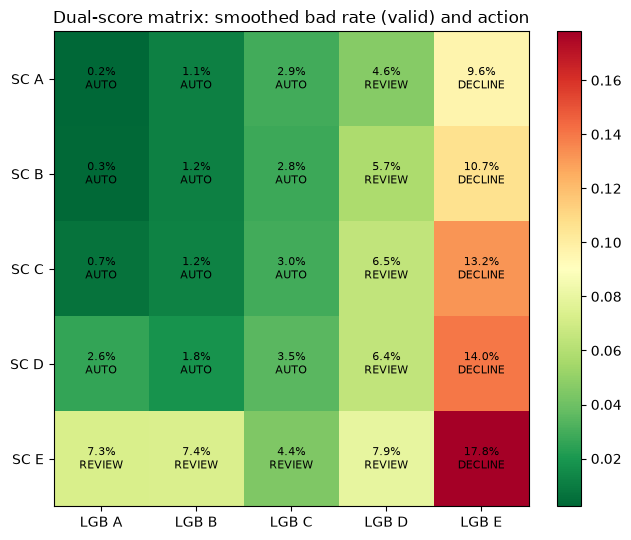

In [4]:
order = grid.sort("bad_rate_sm").with_columns(pl.col("share").cum_sum().alias("cum"))
ACTION = {}
for r in order.iter_rows(named=True):
    mid = r["cum"] - r["share"] / 2
    ACTION[(r["g_sc"], r["g_lgb"])] = "auto-approve" if mid <= AUTO_SHARE else "manual review" if mid <= AUTO_SHARE + REVIEW_SHARE else "decline"
rank = {"auto-approve": 0, "manual review": 1, "decline": 2}
inv = {v: k for k, v in rank.items()}
R = np.array([[rank[ACTION[(i, j)]] for j in range(5)] for i in range(5)])
for i in range(5):
    for j in range(5):
        R[i, j] = max(R[i, j], R[i - 1, j] if i else 0, R[i, j - 1] if j else 0)
ACTION = {(i, j): inv[R[i, j]] for i in range(5) for j in range(5)}

M = np.array([[grid.filter((pl.col("g_sc") == i) & (pl.col("g_lgb") == j))["bad_rate_sm"][0] for j in range(5)] for i in range(5)])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(M, cmap="RdYlGn_r")
short = {"auto-approve": "AUTO", "manual review": "REVIEW", "decline": "DECLINE"}
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{M[i, j]:.1%}\n{short[ACTION[(i, j)]]}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(5)); ax.set_xticklabels([f"LGB {g}" for g in GRADE_LABELS])
ax.set_yticks(range(5)); ax.set_yticklabels([f"SC {g}" for g in GRADE_LABELS])
ax.set_title("Dual-score matrix: smoothed bad rate (valid) and action"); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); savefig(fig, "10_dual_score_matrix"); plt.show()

**Baseline at equal shares:** the scorecard alone, cut so that its auto-approve and review shares on valid equal
the matrix's. Compare the auto-approve bad rate and bads per 10,000 applications.

In [5]:
act_tab = pl.DataFrame([{"g_sc": i, "g_lgb": j, "act_matrix": a} for (i, j), a in ACTION.items()]).cast(
    {"g_sc": P["g_sc"].dtype, "g_lgb": P["g_lgb"].dtype})
P = P.join(act_tab, on=["g_sc", "g_lgb"], how="left")
V = P.filter(pl.col("period") == "2_valid")
auto_v, rev_v = (V["act_matrix"] == "auto-approve").mean(), (V["act_matrix"] == "manual review").mean()
c_auto = float(np.quantile(V["s_sc"].to_numpy(), 1 - auto_v))
c_rev = float(np.quantile(V["s_sc"].to_numpy(), 1 - auto_v - rev_v))
P = P.with_columns(pl.when(pl.col("s_sc") >= c_auto).then(pl.lit("auto-approve"))
                     .when(pl.col("s_sc") >= c_rev).then(pl.lit("manual review")).otherwise(pl.lit("decline")).alias("act_single"))


def summarize(col):
    rows = []
    for p in EVAL:
        d = P.filter(pl.col("period") == p)
        r = {"period": PERIOD_LABEL[p]}
        for act in ("auto-approve", "manual review", "decline"):
            s = d.filter(pl.col(col) == act)
            r[f"{act} share"] = s.height / d.height
            r[f"{act} bad rate"] = float(s["target"].mean()) if s.height else float("nan")
        r["auto-approved bads per 10k"] = d.filter(pl.col(col) == "auto-approve")["target"].sum() / d.height * 1e4
        rows.append(r)
    return pl.DataFrame(rows)


matrix_cmp = pl.concat([summarize("act_single").with_columns(pl.lit("scorecard only").alias("policy")),
                        summarize("act_matrix").with_columns(pl.lit("dual-score matrix").alias("policy"))])
print(f"valid shares: auto-approve {auto_v:.1%}, manual review {rev_v:.1%}")
display(matrix_cmp.select(["policy", "period"] + [c for c in matrix_cmp.columns if c not in ("policy", "period")])
                  .with_columns(pl.exclude("policy", "period").round(4)))

valid shares: auto-approve 74.5%, manual review 15.5%


policy,period,auto-approve share,auto-approve bad rate,manual review share,manual review bad rate,decline share,decline bad rate,auto-approved bads per 10k
str,str,f64,f64,f64,f64,f64,f64,f64
"""scorecard only""","""Valid""",0.7476,0.0162,0.1548,0.0664,0.0975,0.1432,121.1209
"""scorecard only""","""OOT1""",0.7333,0.019,0.155,0.0729,0.1117,0.1531,139.3586
"""scorecard only""","""OOT2""",0.7803,0.0094,0.1283,0.0449,0.0914,0.1076,73.5466
"""dual-score matrix""","""Valid""",0.7449,0.013,0.1551,0.0657,0.1,0.1648,96.9208
"""dual-score matrix""","""OOT1""",0.7399,0.0158,0.1557,0.076,0.1044,0.1803,116.8403
"""dual-score matrix""","""OOT2""",0.8026,0.0085,0.1263,0.0508,0.0712,0.1362,68.4073


**Full-data reading:** at ~75% auto-approval, the matrix lowers bads per 10k applications by ~21% on valid and ~14%
in OOT1. The action pattern is essentially **LightGBM-led with a scorecard backstop** (LightGBM D → review,
LightGBM E → decline; the scorecard overrides only at grade E). Adopting it therefore requires LightGBM reason codes
(e.g. SHAP-based) for adverse-action explanations — the interpretability requirement moves, it does not disappear.

## 3. Roll-out summary

In [6]:
policy = json.loads((RES_DIR / "09_policy.json").read_text())
policy["challenger_rollout"] = {
    "phase_0_shadow": "LightGBM scores all applications; decisions unchanged; track its ranking on matured loans",
    "phase_1_review_triage": {"rule": f"within scorecard grade D, fast-approve if LightGBM PD <= {-T_FAST:.4f}" if np.isfinite(T_FAST) else "no safe slice found",
                              "safety_margin": f"fast-approve bad rate <= {FAST_SAFETY:.0%} of grade C on valid",
                              "valid_effect": review.filter(pl.col("period") == "Valid").drop("period").row(0, named=True)},
    "phase_2_dual_matrix": {"actions": {f"SC{GRADE_LABELS[i]}-LGB{GRADE_LABELS[j]}": ACTION[(i, j)] for i in range(5) for j in range(5)},
                            "valid_shares": {"auto-approve": round(auto_v, 4), "manual review": round(rev_v, 4)},
                            "prerequisite": "LightGBM reason codes for declined applicants"},
}
(RES_DIR / "10_final_policy.json").write_text(json.dumps(policy, indent=1))
review.write_csv(RES_DIR / "10_review_triage.csv", include_bom=True)
matrix_cmp.write_csv(RES_DIR / "10_dual_matrix.csv", include_bom=True)
print(json.dumps(policy["challenger_rollout"], indent=1)[:1500])

{
 "phase_0_shadow": "LightGBM scores all applications; decisions unchanged; track its ranking on matured loans",
 "phase_1_review_triage": {
  "rule": "within scorecard grade D, fast-approve if LightGBM PD <= 0.0300",
  "safety_margin": "fast-approve bad rate <= 90% of grade C on valid",
  "valid_effect": {
   "grade_D_share": 0.1471,
   "fast_approve_share": 0.0471,
   "review_workload_cut": 0.3202,
   "bad_rate_fast_approve": 0.031,
   "bad_rate_grade_C": 0.0345,
   "bad_rate_remaining_review": 0.0845,
   "bad_rate_grade_D": 0.0674
  }
 },
 "phase_2_dual_matrix": {
  "actions": {
   "SCA-LGBA": "auto-approve",
   "SCA-LGBB": "auto-approve",
   "SCA-LGBC": "auto-approve",
   "SCA-LGBD": "manual review",
   "SCA-LGBE": "decline",
   "SCB-LGBA": "auto-approve",
   "SCB-LGBB": "auto-approve",
   "SCB-LGBC": "auto-approve",
   "SCB-LGBD": "manual review",
   "SCB-LGBE": "decline",
   "SCC-LGBA": "auto-approve",
   "SCC-LGBB": "auto-approve",
   "SCC-LGBC": "auto-approve",
   "SCC-LGBD": 